In [ ]:
import os
from spatialdata.models import Image2DModel
import numpy as np
import tifffile
import spatialdata as sd
import pandas as pd
from skimage.measure import regionprops_table
import spatialdata_plot
import spatialdata_io
import matplotlib.pyplot as plt
import seaborn as sns
import zarr
from copy import copy
import matplotlib.colors as mcolors
import dask.array as da
import skimage.measure
import xmltodict
from spatialdata import SpatialData
import spatialdata as sd
import cv2

%config InlineBackend.figure_format = 'retina'


/data1/lowes/reyesj3/miniconda3/envs/spatialdata_opencv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data1/lowes/reyesj3/miniconda3/envs/spatialdata_opencv/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [ ]:
import importlib.util
import sys
def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
imaging_utils =  lazy_import("imaging_utils",os.path.join(utils_dir, "imaging_utils.py"))
from general_utils import ismember, grep, grep_exclude
from imaging_utils import imnormalize, im2rgb, imblend, imoverlay, rolling_ball_filter


In [ ]:
SLIDE_ID = "SLIDE-0293"
sdata_path = os.path.join("../sdata", SLIDE_ID)
sdata = sd.read_zarr(sdata_path)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-

In [ ]:
channels = np.array(sd.models.get_channel_names(sdata.images["celldive"])).tolist()
def get_image(sdata, key, scale, channel):
    idx = channels.index(channel)
    return sdata.images[key][scale].image[idx].values

scale = "scale2"
img_nucleus = get_image(sdata, "celldive", scale, "DAPI")
img_cytoplasm = get_image(sdata, "celldive", scale, "PanCK")

In [ ]:
img_nucleus_norm = imnormalize(img_nucleus)
img_cytoplasm_norm = imnormalize(img_cytoplasm)
img_cellpose = np.array([img_nucleus_norm,img_cytoplasm_norm,])
img_cellpose_nucleus = np.array([img_nucleus_norm])

In [ ]:
import cv2
nucleus_thumb = cv2.resize(img_nucleus_norm, None, fx = 0.1, fy = 0.1, interpolation=cv2.INTER_LINEAR)
cyto_thumb = cv2.resize(img_cytoplasm_norm, None, fx = 0.1, fy = 0.1, interpolation=cv2.INTER_LINEAR)

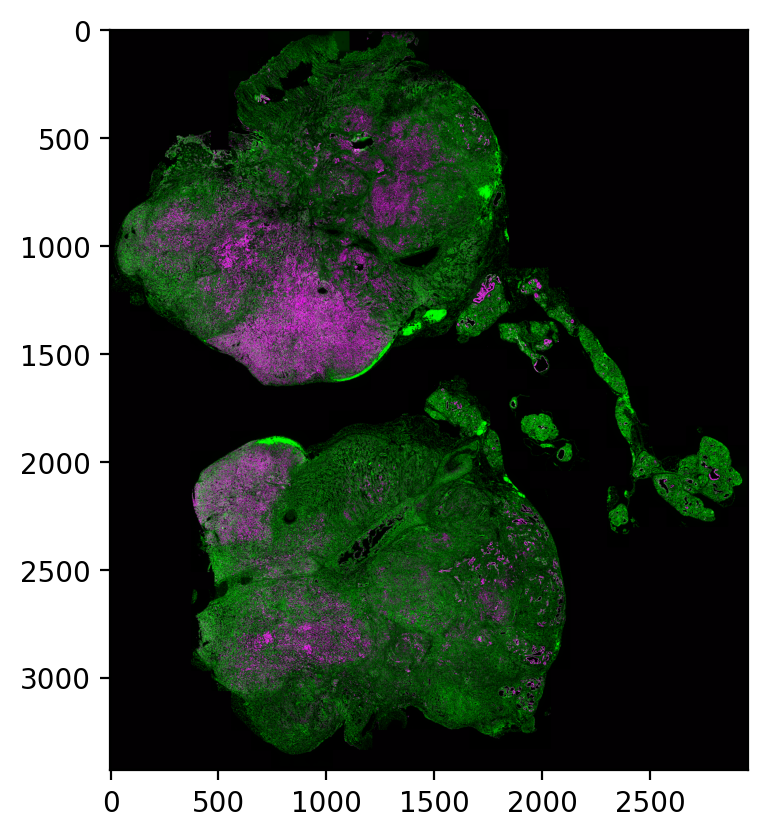

In [ ]:
plt.imshow(imblend(nucleus_thumb, cyto_thumb, cyto_thumb))

In [ ]:
os.makedirs("../cellpose_masks_cyto", exist_ok= True)
mask_path = os.path.join("../cellpose_masks_cyto", SLIDE_ID + "masks.npz")
if os.path.exists(mask_path):
    print("Reading existing masks")
    masks_full = np.load(mask_path)['arr_0']
else:
    print("Running cellpose")

    import cellpose.models

    # model parameters
    flow_threshold = 0.4
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0
    
    # run cellpose
    model = cellpose.models.CellposeModel(gpu=True)
    masks, flows, styles = model.eval(
        img_cellpose,
        batch_size=64,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize}
    )
    
    shape_full = sdata.images["celldive"]["scale0"].image.shape[1:]
    
    # scale to full shape, do not interpolate
    import skimage.transform
    masks_full = skimage.transform.resize(masks, shape_full, order=0, preserve_range=True)
    
    assert masks_full.shape == shape_full, f"Mask full shape {masks_full.shape} not equal to full shape {shape_full}"
    
    # add to spatialdata
    
    #sdata.write_element("cellpose_masks", overwrite = True)
    np.savez_compressed(mask_path, masks_full)

print("Adding masks to sdata")
sdata.images["cellpose_masks_cyto"] = sd.models.Image2DModel.parse(masks_full[np.newaxis, ...], dims=["c", "y", "x"])


In [ ]:
os.makedirs("../cellpose_masks_nucleus", exist_ok= True)
mask_path = os.path.join("../cellpose_masks_nucleus", SLIDE_ID + "masks.npz")
if os.path.exists(mask_path):
    print("Reading existing masks")
    masks_full_nucleus = np.load(mask_path)['arr_0']
else:
    print("Running cellpose")

    import cellpose.models

    # model parameters
    flow_threshold = 0.4
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0
    
    # run cellpose
    model = cellpose.models.CellposeModel(gpu=True)
    masks, flows, styles = model.eval(
        img_cellpose_nucleus,
        batch_size=64,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize}
    )
    
    shape_full = sdata.images["celldive"]["scale0"].image.shape[1:]
    
    # scale to full shape, do not interpolate
    import skimage.transform
    masks_full_nucleus = skimage.transform.resize(masks, shape_full, order=0, preserve_range=True)
    
    assert masks_full_nucleus.shape == shape_full, f"Mask full shape {masks_full_nucleus.shape} not equal to full shape {shape_full}"
    
    # add to spatialdata
    
    #sdata.write_element("cellpose_masks", overwrite = True)
    np.savez_compressed(mask_path, masks_full_nucleus)

print("Adding masks to sdata")
sdata.images["cellpose_masks_nucleus"] = sd.models.Image2DModel.parse(masks_full_nucleus[np.newaxis, ...], dims=["c", "y", "x"])


### Verify output

In [ ]:
mask_cyto_thumb = cv2.resize(masks_full.astype(np.float32), None, fx = 0.05, fy = 0.05, interpolation=cv2.INTER_LINEAR)
mask_nucleus_thumb = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.05, fy = 0.05, interpolation=cv2.INTER_LINEAR)

mask_cyto_reference = cv2.resize(masks_full.astype(np.float32), None, fx = 0.5, fy = 0.5, interpolation=cv2.INTER_LINEAR)
mask_nucleus_reference = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.5, fy = 0.5, interpolation=cv2.INTER_LINEAR)

In [ ]:
bounds = [[11500,12500], [5000,6000]]
bounds = [[7500,10000], [0,2500]]
zoom_nucleus = img_nucleus_norm[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
zoom_cyto = img_cytoplasm_norm[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
zoom_mask = mask_cyto_reference[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
plt.imshow(imoverlay(imblend(zoom_nucleus, zoom_cyto, zoom_cyto), zoom_mask, [1,1,1], px=2))

### Consolidate nucleus and cytoplasmic masks

In [ ]:
unique_values_full = np.unique(np.ravel(masks_full))
print("Total cells in cytoplasmic mask: " + str(len(unique_values_full)))

In [ ]:
mask_cyto_mask = np.multiply(masks_full, (masks_full_nucleus > 0).astype(np.uint8))
unique_values = np.unique(np.ravel(mask_cyto_mask))
print("Total cells in after intersecting with nuclear mask: " + str(len(unique_values)))

In [ ]:
mask_cyto_final = np.multiply(masks_full, np.isin(masks_full, unique_values).astype(np.uint8))
unique_values_final = np.unique(np.ravel(mask_cyto_final))
print("Kept: " + str(len(unique_values_final) / len(unique_values_full)))

In [ ]:
os.makedirs("../cellpose_masks_consolidated", exist_ok = True)
mask_path = os.path.join("../cellpose_masks_consolidated", SLIDE_ID + "_masks_nucleus_consolidated.npz")
np.savez_compressed(mask_path, mask_cyto_mask)
mask_path = os.path.join("../cellpose_masks_consolidated", SLIDE_ID + "_masks_cyto_consolidated.npz")
np.savez_compressed(mask_path, mask_cyto_final)